DSCI 552 Final Project

Name: Brynn Dafoe GitHub Username: brynndafoe02 USD ID: 3109-6692-10

In [2]:
import cv2
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
from PIL import Image
import re
import seaborn as sns

from sklearn import datasets
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV, RidgeCV, LassoCV
from sklearn.metrics import silhouette_score, hamming_loss, RocCurveDisplay, roc_auc_score, accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, cross_val_score, RepeatedKFold, KFold
from sklearn.pipeline import Pipeline as SPipeline
from sklearn.preprocessing import StandardScaler, label_binarize, OneHotEncoder

import statsmodels.api as sm
import statsmodels.formula.api as smf

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0, VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data_path = "/content/drive/MyDrive/defungi"

Objective:
- Trying to build a classifier that distinguishes images of FIVE types of waste

Data Exploration and Pre-Processing
- Images are numbered in each folder
- Select FIRST 80% of the images in EACH FOLDER as your TRAINING set
- - Use the rest as the TEST set
  - Can you encode classes using one-hot encoding
- In case all the images do not have the same size, ZERO-PAD or RESIZE the images in your dataset
- - This can be done using various tools, including OpenCV

In [5]:
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224

In [6]:
# 80% Training, 20% Testing
    # Will take the 20% Validation Set from the training set now as well
    # So for the 80% training: 64% for actual training, 16% for VS

In [7]:
defungi_path = Path(data_path)
waste_class_names = ["C1", "C2", "C3", "C4", "C5"]

In [8]:
# to make sure the images get sorted correctly
    # aka: making sure H1_100a_3.jpg comes before H1_101a_1.jpg, etc.
def natural_sorting(path_to_image):
    return [
        int(c) if c.isdigit() else c.lower()
        for c in re.split(r'(\d+)', path_to_image.name)
    ]

In [9]:
training_paths = []
training_labels = []

testing_paths = []
testing_labels = []

valset_paths = []
valset_labels = []

# parallel lists: ex -> training_paths has the image paths, training_labels has the class labels
# I'm keeping these separate cause I don't want to deal with a dictionary


In [10]:
cw_index = 0
for waste_class in waste_class_names:
    waste_class_folder = defungi_path / waste_class
    # makes the path to the inner folder from the outer defungi folder
        # so now "../data/defungi/C1" for example

    image_files_list = list(waste_class_folder.glob("*.jpg"))
    sorted_filenames = sorted(image_files_list, key=natural_sorting) # NATURALLY sort all the image files

    tt_split_index = int(0.80 * len(sorted_filenames))

    # training + validation all together first
    training_validation_set = sorted_filenames[:tt_split_index]
    # testing set, can leave this alone
    testing_image_paths = sorted_filenames[tt_split_index:]

    # splitting into true training set and true validation set
    # random 20% of train+val set will go to validation_image_paths, other 80% to training
    training_image_paths, validation_image_paths = train_test_split(training_validation_set, test_size=0.20, random_state=42, shuffle=True)

    #####

    training_paths.extend(training_image_paths)
    train_class_label_list = [cw_index] * len(training_image_paths)
    training_labels.extend(train_class_label_list)

    testing_paths.extend(testing_image_paths)
    test_class_label_list = [cw_index] * len(testing_image_paths)
    testing_labels.extend(test_class_label_list)

    valset_paths.extend(validation_image_paths)
    val_class_label_list = [cw_index] * len(validation_image_paths)
    valset_labels.extend(val_class_label_list)

    cw_index+=1


In [11]:
# resnet50, resnet101, efficientnetb0, and vgg16 take: 224 x 224 picels with 3 color channels
    # resnet + efficientnet -> expect RGB
    # vgg16 -> expects BGR
        # preprocess will convert back later, to make simple going to convert all to RGB now
def resize_zeropad_images(image_paths):
    fixed_images = []
    for image_path in image_paths:
        image = cv2.imread(str(image_path))
        if image is None:
            raise ValueError(f"Could not load image")

        # convert all to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        og_h, og_w = image.shape[:2]

        scale = min(IMAGE_HEIGHT / og_h, IMAGE_WIDTH / og_w)

        # new dimensions
        new_w = int(og_w * scale)
        new_h = int(og_h * scale)

        # resize image
        resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

        top = (IMAGE_HEIGHT - new_h) // 2
        bottom = IMAGE_HEIGHT - new_h - top
        left = (IMAGE_WIDTH - new_w) // 2
        right = IMAGE_WIDTH - new_w - left

        # zero padding image
        padded_image = cv2.copyMakeBorder(
            resized_image, top, bottom, left, right,
            borderType=cv2.BORDER_CONSTANT,
            value=[0, 0, 0]
        )

        fixed_images.append(padded_image)

    return fixed_images


In [12]:
X_train = np.array(resize_zeropad_images(training_paths))
X_test= np.array(resize_zeropad_images(testing_paths))
X_val = np.array(resize_zeropad_images(valset_paths))

encoder = OneHotEncoder(sparse_output=False)

Y_train = encoder.fit_transform(np.array(training_labels).reshape(-1, 1))
Y_test = encoder.transform(np.array(testing_labels).reshape(-1, 1))
Y_val = encoder.transform(np.array(valset_labels).reshape(-1, 1))

Transfer Learning i
- Transfer learning for small image datasets
- - uses deep learning models that are trained on large datasets as feature extractors
  - these deep networks have learned to extract meaningful features from an image using their layers, thos features can be used in learning other tasks
- Usually last / last few layers of the pre-trained network are removed, and the response of the layer before the removed layers to the images in the new dataset is used as a feature vector to train one more multiple replacement layers
- Will use pre-trained models: ResNet50, ResNet101, EfficientNetB0, and VGG16
- - will only train LAST fully connected layer, and will FREEZE all layers before them (we do not change their parameters during training)
  - will use the outputs of the penultimate layer in the original pre-trained model as the features extracted from each image

Transfer Learning ii
- To perform empirical regularization, crop, randomly zoom, rotate, flip, contrast, and translate images in your training set for image augmentation
- - can use various tools to do this (including OpenCV)

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomCrop(180, 180),
    layers.RandomZoom(0.2),
    layers.RandomRotation(0.2),
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.Resizing(224, 224)
])
# need resize at end because need 224x224

In [14]:
# ResNet50
# load base model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# freeze all layers in base model
base_model.trainable = False
# build final model
inputs = keras.Input(shape=(224, 224, 3))
# augment images
x = data_augmentation(inputs)
# specific preprocess for model to make images be correct for model
x = resnet_preprocess(x)
# pass augmented / pre-processed images through ResNet
x = base_model(x, training=False)
    # false keeps BatchNormalization in inference mode
x = layers.GlobalAveragePooling2D()(x)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [15]:
# ReLu activation functions in dense layer
# L2 regularization
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
    # 256 neurons was recomended for the training size and number of classes
    # 0.001 as a middle ground penalty
# batch normalization
x = layers.BatchNormalization()(x)
# dropout rate of 20%
x = layers.Dropout(0.2)(x)
# softmax layer -> needs to be last / last layer
outputs = layers.Dense(5, activation="softmax")(x)

Transfer Learning iii
- Use ReLu activation functions in the last layer and softmax layer, along with L2 regularization, batch normalization, dropout rate of 20% as well as ADAM optimizer
- Use multinomial cross entropy loss
- You can try any batch size, but a batch size of 5 seems reasonable

In [16]:
# ADAM optimizer
# multinomial cross entropy loss
resnet50_fm = keras.Model(inputs=inputs, outputs=outputs)
resnet50_fm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss="categorical_crossentropy",
                   metrics=["accuracy"])

Transfer Learning iv
- Train the networs for at least 50 epochs (preferably 100 epochs) and perform early stopping using the validation set
- Use a randomly selected subset of 20% of each class as the validation set
- Keep the network parameters that have the lowest validation error
- Plot the training and validation errors vs. epochs

In [17]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1,
    start_from_epoch=50
)
# lowest validation error
# patience 10 -> good for deep networks like ResNet50

checkpoint = ModelCheckpoint(
    "best_resnet50.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

history_resnet50 = resnet50_fm.fit(
    X_train,
    Y_train,
    batch_size=5,
    epochs=100,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, checkpoint]
)

resnet50_fm.load_weights("best_resnet50.weights.h5")

Epoch 1/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5700 - loss: 1.4934
Epoch 1: val_loss improved from None to 0.99790, saving model to best_resnet50.weights.h5

Epoch 1: finished saving model to best_resnet50.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 63s 42ms/step - accuracy: 0.6063 - loss: 1.2780 - val_accuracy: 0.6945 - val_loss: 0.9979
Epoch 2/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6549 - loss: 1.0444
Epoch 2: val_loss improved from 0.99790 to 0.87774, saving model to best_resnet50.weights.h5

Epoch 2: finished saving model to best_resnet50.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step - accuracy: 0.6520 - loss: 1.0317 - val_accuracy: 0.7267 - val_loss: 0.8777
Epoch 3/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6772 - loss: 0.9525
Epoch 3: val_loss did not improve from 0.87774
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.6660 - loss: 0.9831 - val_accuracy: 0.7116 - val_loss: 0.9100
Epoch 4/100
1165/

In [18]:
# RESNET101 NOW
base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = resnet_preprocess(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(5, activation="softmax")(x)

resnet101_fm = keras.Model(inputs=inputs, outputs=outputs)
resnet101_fm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss="categorical_crossentropy",
                   metrics=["accuracy"])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1,
    start_from_epoch=50
)

checkpoint = ModelCheckpoint(
    "best_resnet101.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

history_resnet101 = resnet101_fm.fit(
    X_train,
    Y_train,
    batch_size=5,
    epochs=100,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, checkpoint]
)

resnet101_fm.load_weights("best_resnet101.weights.h5")

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/100
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5509 - loss: 1.5079
Epoch 1: val_loss improved from None to 0.90581, saving model to best_resnet101.weights.h5

Epoch 1: finished saving model to best_resnet101.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 95s 70ms/step - accuracy: 0.6077 - loss: 1.2617 - val_accuracy: 0.7308 - val_loss: 0.9058
Epoch 2/100
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6546 - loss: 1.0473
Epoch 2: val_loss improved from 0.90581 to 0.78908, saving model to best_resnet101.weights.h5

Epoch 2: finished saving model to best_resnet101.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - accuracy: 0.6552 - loss: 1.0281 - val_accuracy: 0.7527 - val_loss: 0.7891
Epoch 3/100
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6802 - loss: 0.9645
Epoch 3: val_loss improved from 0.78908 to 0.78389, saving model to best_resnet101.weights.h5

Epoch 3: finished saving model to

In [19]:
# EfficientNetB0 NOW
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = effnet_preprocess(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(5, activation="softmax")(x)

effnet_fm = keras.Model(inputs=inputs, outputs=outputs)
effnet_fm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss="categorical_crossentropy",
                   metrics=["accuracy"])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1,
    start_from_epoch=50
)

checkpoint = ModelCheckpoint(
    "best_effnet.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

history_effnet = effnet_fm.fit(
    X_train,
    Y_train,
    batch_size=5,
    epochs=100,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, checkpoint]
)

effnet_fm.load_weights("best_effnet.weights.h5")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5136 - loss: 1.6462
Epoch 1: val_loss improved from None to 1.07118, saving model to best_effnet.weights.h5

Epoch 1: finished saving model to best_effnet.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.5698 - loss: 1.4269 - val_accuracy: 0.7082 - val_loss: 1.0712
Epoch 2/100
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6252 - loss: 1.1924
Epoch 2: val_loss improved from 1.07118 to 0.93354, saving model to best_effnet.weights.h5

Epoch 2: finished saving model to best_effnet.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - accuracy: 0.6288 - loss: 1.1715 - val_accuracy: 0.7007 - val_loss: 0.9335
Epoch 3/100
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6343 - loss: 1.0824
Epoch 3: val_loss did not improve from 0.93354
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.6348 - loss: 1.0779 - val_accuracy: 

In [20]:
# VGG16 NOW
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = vgg_preprocess(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(5, activation="softmax")(x)

vgg_fm = keras.Model(inputs=inputs, outputs=outputs)
vgg_fm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss="categorical_crossentropy",
                   metrics=["accuracy"])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1,
    start_from_epoch=50
)

checkpoint = ModelCheckpoint(
    "best_vgg.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

history_vgg = vgg_fm.fit(
    X_train,
    Y_train,
    batch_size=5,
    epochs=100,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, checkpoint]
)

vgg_fm.load_weights("best_vgg.weights.h5")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5508 - loss: 1.4513
Epoch 1: val_loss improved from None to 1.06996, saving model to best_vgg.weights.h5

Epoch 1: finished saving model to best_vgg.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 62s 50ms/step - accuracy: 0.5828 - loss: 1.2946 - val_accuracy: 0.6610 - val_loss: 1.0700
Epoch 2/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6329 - loss: 1.0924
Epoch 2: val_loss improved from 1.06996 to 1.00457, saving model to best_vgg.weights.h5

Epoch 2: finished saving model to best_vgg.weights.h5
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 57s 49ms/step - accuracy: 0.6341 - loss: 1.0840 - val_accuracy: 0.6753 - val_loss: 1.0046
Epoch 3/100
1165/1166 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6418 - loss: 1.0308
Epoch 3: val_loss did not improve from 1.00457
1166/1166 ━━━━━━━━━━━━━━━━━━━━ 57s 49ms/step - accuracy: 0.6336 - loss: 1.0435 - val_accuracy: 0.6671 - val

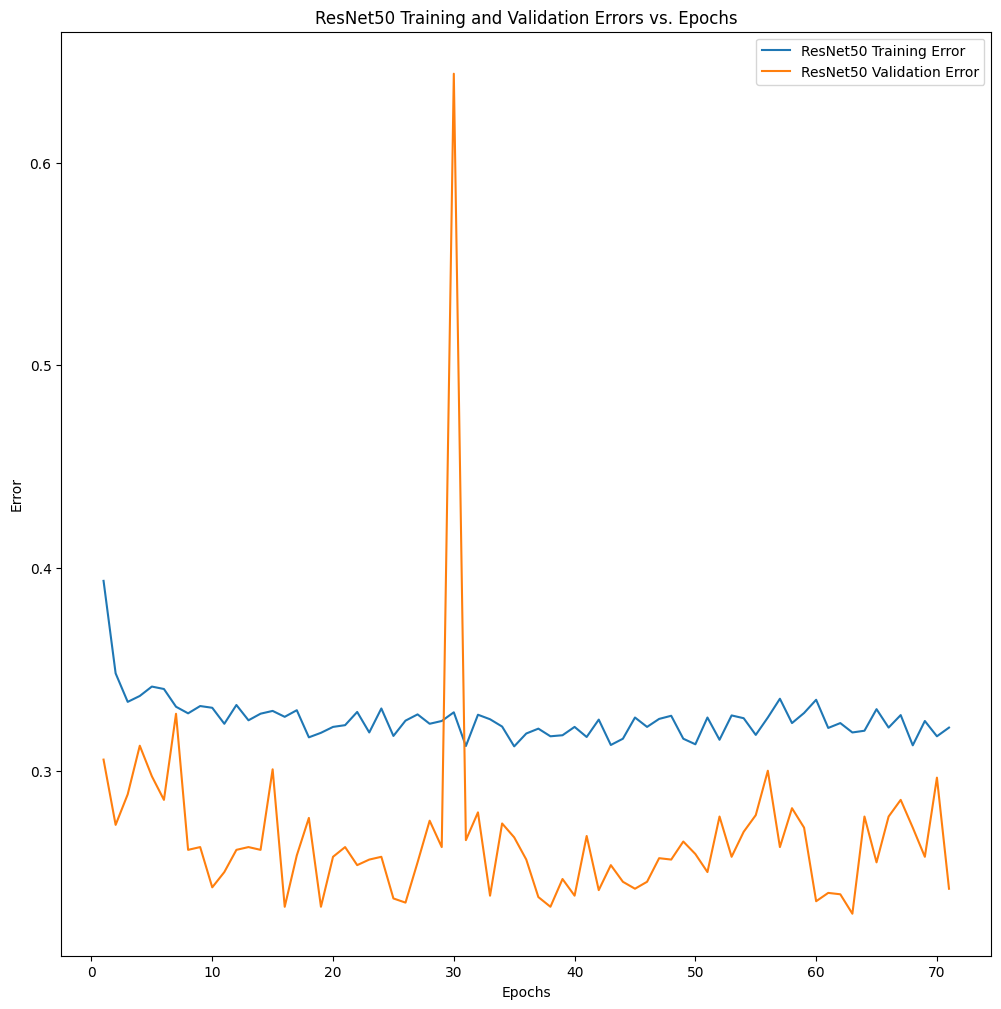

183/183 ━━━━━━━━━━━━━━━━━━━━ 33s 155ms/step
ResNet50 TRAINING Scores:
	Precision: 0.7632940990633176
	Recall: 0.7614065180102916
	F1 Score: 0.7390236292270311
	AUC: 0.900882331952631
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step
ResNet50 TESTING Scores:
	Precision: 0.5793368608150034
	Recall: 0.6014254385964912
	F1 Score: 0.5516073392106192
	AUC: 0.8020653452129997
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step
ResNet50 VALIDATION Scores:
	Precision: 0.7633250181921399
	Recall: 0.7602739726027398
	F1 Score: 0.7405282754500903
	AUC: 0.9003461334765609


In [21]:
# ResNet50 plot training and validation errors vs. epochs
resnet50_train_acc = np.array(history_resnet50.history['accuracy'])
resnet50_val_acc = np.array(history_resnet50.history['val_accuracy'])
resnet50_train_error = 1 - resnet50_train_acc
resnet50_val_error = 1 - resnet50_val_acc
resnet50_epochs = np.arange(1, len(resnet50_train_error) + 1)

plt.figure(figsize=(12, 12))
plt.plot(resnet50_epochs, resnet50_train_error, label='ResNet50 Training Error')
plt.plot(resnet50_epochs, resnet50_val_error, label='ResNet50 Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("ResNet50 Training and Validation Errors vs. Epochs")
plt.legend()
plt.show()

# training Precision, Recall, AUC, F1 Score
rn50_Y_train_probs = resnet50_fm.predict(X_train)

rn50_Y_train_true = np.argmax(Y_train, axis=1)
rn50_Y_train_pred = np.argmax(rn50_Y_train_probs, axis=1)

rn50_train_precision = precision_score(rn50_Y_train_true, rn50_Y_train_pred, average='weighted', zero_division=0)
rn50_train_recall = recall_score(rn50_Y_train_true, rn50_Y_train_pred, average='weighted', zero_division=0)
rn50_train_f1 = f1_score(rn50_Y_train_true, rn50_Y_train_pred, average='weighted', zero_division=0)
rn50_train_auc = roc_auc_score(Y_train, rn50_Y_train_probs, average='weighted', multi_class='ovr')

print("ResNet50 TRAINING Scores:")
print(f"\tPrecision: {rn50_train_precision}")
print(f"\tRecall: {rn50_train_recall}")
print(f"\tF1 Score: {rn50_train_f1}")
print(f"\tAUC: {rn50_train_auc}")

# testing Precision, Recall, AUC, F1 Score
rn50_Y_test_probs = resnet50_fm.predict(X_test)

rn50_Y_test_true = np.argmax(Y_test, axis=1)
rn50_Y_test_pred = np.argmax(rn50_Y_test_probs, axis=1)

rn50_test_precision = precision_score(rn50_Y_test_true, rn50_Y_test_pred, average='weighted', zero_division=0)
rn50_test_recall = recall_score(rn50_Y_test_true, rn50_Y_test_pred, average='weighted', zero_division=0)
rn50_test_f1 = f1_score(rn50_Y_test_true, rn50_Y_test_pred, average='weighted', zero_division=0)
rn50_test_auc = roc_auc_score(Y_test, rn50_Y_test_probs, average='weighted', multi_class='ovr')

print("ResNet50 TESTING Scores:")
print(f"\tPrecision: {rn50_test_precision}")
print(f"\tRecall: {rn50_test_recall}")
print(f"\tF1 Score: {rn50_test_f1}")
print(f"\tAUC: {rn50_test_auc}")

# validation Precision, Recall, AUC, F1 Score
rn50_Y_val_probs = resnet50_fm.predict(X_val)

rn50_Y_val_true = np.argmax(Y_val, axis=1)
rn50_Y_val_pred = np.argmax(rn50_Y_val_probs, axis=1)

rn50_val_precision = precision_score(rn50_Y_val_true, rn50_Y_val_pred, average='weighted', zero_division=0)
rn50_val_recall = recall_score(rn50_Y_val_true, rn50_Y_val_pred, average='weighted', zero_division=0)
rn50_val_f1 = f1_score(rn50_Y_val_true, rn50_Y_val_pred, average='weighted', zero_division=0)
rn50_val_auc = roc_auc_score(Y_val, rn50_Y_val_probs, average='weighted', multi_class='ovr')

print("ResNet50 VALIDATION Scores:")
print(f"\tPrecision: {rn50_val_precision}")
print(f"\tRecall: {rn50_val_recall}")
print(f"\tF1 Score: {rn50_val_f1}")
print(f"\tAUC: {rn50_val_auc}")


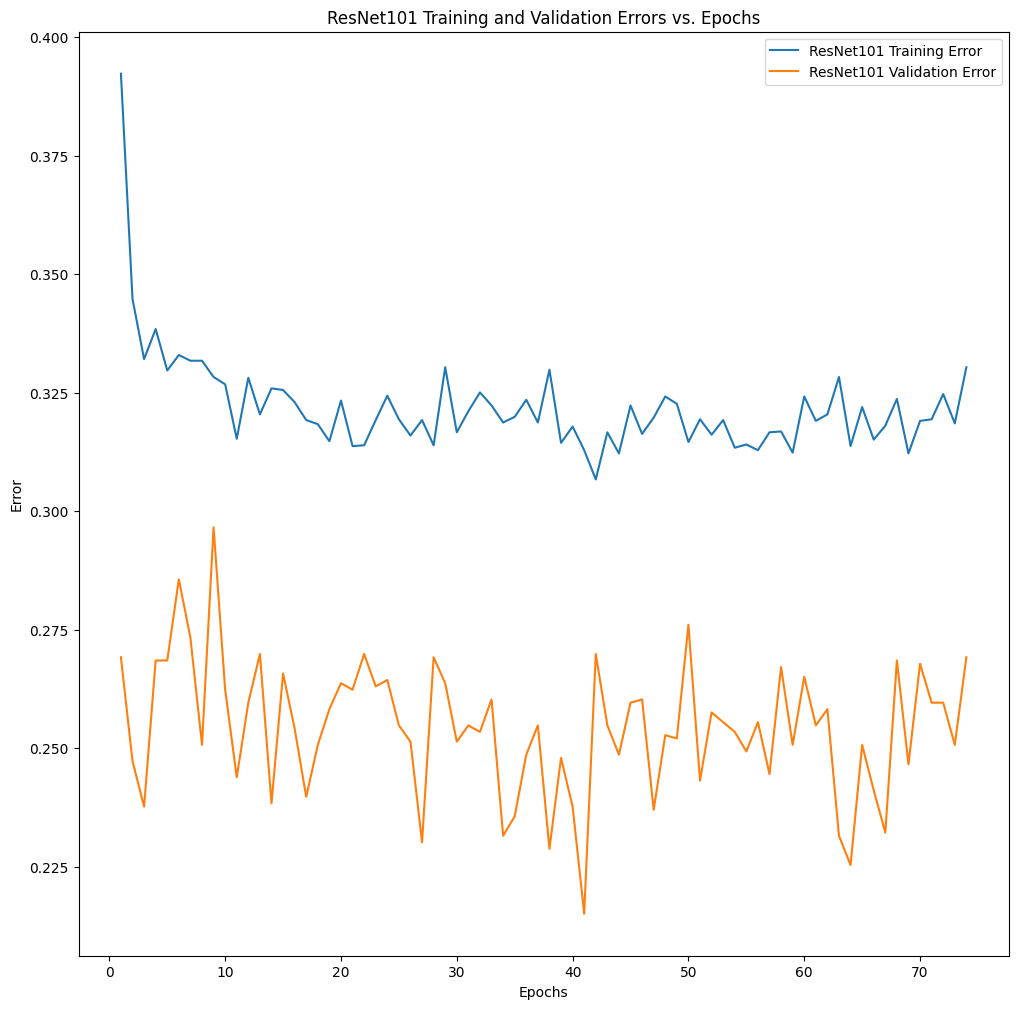

183/183 ━━━━━━━━━━━━━━━━━━━━ 51s 259ms/step
ResNet101 TRAINING Scores:
	Precision: 0.7730052608873454
	Recall: 0.7636363636363637
	F1 Score: 0.7377208094996963
	AUC: 0.9063787091371716
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 225ms/step
ResNet101 TESTING Scores:
	Precision: 0.5821050741475235
	Recall: 0.6156798245614035
	F1 Score: 0.5681385257736883
	AUC: 0.8231495586005405
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step
ResNet101 VALIDATION Scores:
	Precision: 0.7812086737188568
	Recall: 0.7746575342465754
	F1 Score: 0.7538148557649497
	AUC: 0.9072323730706361


In [22]:
# ResNet101 plot training and validation errors vs. epochs
resnet101_train_acc = np.array(history_resnet101.history['accuracy'])
resnet101_val_acc = np.array(history_resnet101.history['val_accuracy'])
resnet101_train_error = 1 - resnet101_train_acc
resnet101_val_error = 1 - resnet101_val_acc
resnet101_epochs = np.arange(1, len(resnet101_train_error) + 1)

plt.figure(figsize=(12, 12))
plt.plot(resnet101_epochs, resnet101_train_error, label='ResNet101 Training Error')
plt.plot(resnet101_epochs, resnet101_val_error, label='ResNet101 Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("ResNet101 Training and Validation Errors vs. Epochs")
plt.legend()
plt.show()

# training Precision, Recall, AUC, F1 Score
rn101_Y_train_probs = resnet101_fm.predict(X_train)

rn101_Y_train_true = np.argmax(Y_train, axis=1)
rn101_Y_train_pred = np.argmax(rn101_Y_train_probs, axis=1)

rn101_train_precision = precision_score(rn101_Y_train_true, rn101_Y_train_pred, average='weighted', zero_division=0)
rn101_train_recall = recall_score(rn101_Y_train_true, rn101_Y_train_pred, average='weighted', zero_division=0)
rn101_train_f1 = f1_score(rn101_Y_train_true, rn101_Y_train_pred, average='weighted', zero_division=0)
rn101_train_auc = roc_auc_score(Y_train, rn101_Y_train_probs, average='weighted', multi_class='ovr')

print("ResNet101 TRAINING Scores:")
print(f"\tPrecision: {rn101_train_precision}")
print(f"\tRecall: {rn101_train_recall}")
print(f"\tF1 Score: {rn101_train_f1}")
print(f"\tAUC: {rn101_train_auc}")

# testing Precision, Recall, AUC, F1 Score
rn101_Y_test_probs = resnet101_fm.predict(X_test)

rn101_Y_test_true = np.argmax(Y_test, axis=1)
rn101_Y_test_pred = np.argmax(rn101_Y_test_probs, axis=1)

rn101_test_precision = precision_score(rn101_Y_test_true, rn101_Y_test_pred, average='weighted', zero_division=0)
rn101_test_recall = recall_score(rn101_Y_test_true, rn101_Y_test_pred, average='weighted', zero_division=0)
rn101_test_f1 = f1_score(rn101_Y_test_true, rn101_Y_test_pred, average='weighted', zero_division=0)
rn101_test_auc = roc_auc_score(Y_test, rn101_Y_test_probs, average='weighted', multi_class='ovr')

print("ResNet101 TESTING Scores:")
print(f"\tPrecision: {rn101_test_precision}")
print(f"\tRecall: {rn101_test_recall}")
print(f"\tF1 Score: {rn101_test_f1}")
print(f"\tAUC: {rn101_test_auc}")

# validation Precision, Recall, AUC, F1 Score
rn101_Y_val_probs = resnet101_fm.predict(X_val)

rn101_Y_val_true = np.argmax(Y_val, axis=1)
rn101_Y_val_pred = np.argmax(rn101_Y_val_probs, axis=1)

rn101_val_precision = precision_score(rn101_Y_val_true, rn101_Y_val_pred, average='weighted', zero_division=0)
rn101_val_recall = recall_score(rn101_Y_val_true, rn101_Y_val_pred, average='weighted', zero_division=0)
rn101_val_f1 = f1_score(rn101_Y_val_true, rn101_Y_val_pred, average='weighted', zero_division=0)
rn101_val_auc = roc_auc_score(Y_val, rn101_Y_val_probs, average='weighted', multi_class='ovr')

print("ResNet101 VALIDATION Scores:")
print(f"\tPrecision: {rn101_val_precision}")
print(f"\tRecall: {rn101_val_recall}")
print(f"\tF1 Score: {rn101_val_f1}")
print(f"\tAUC: {rn101_val_auc}")

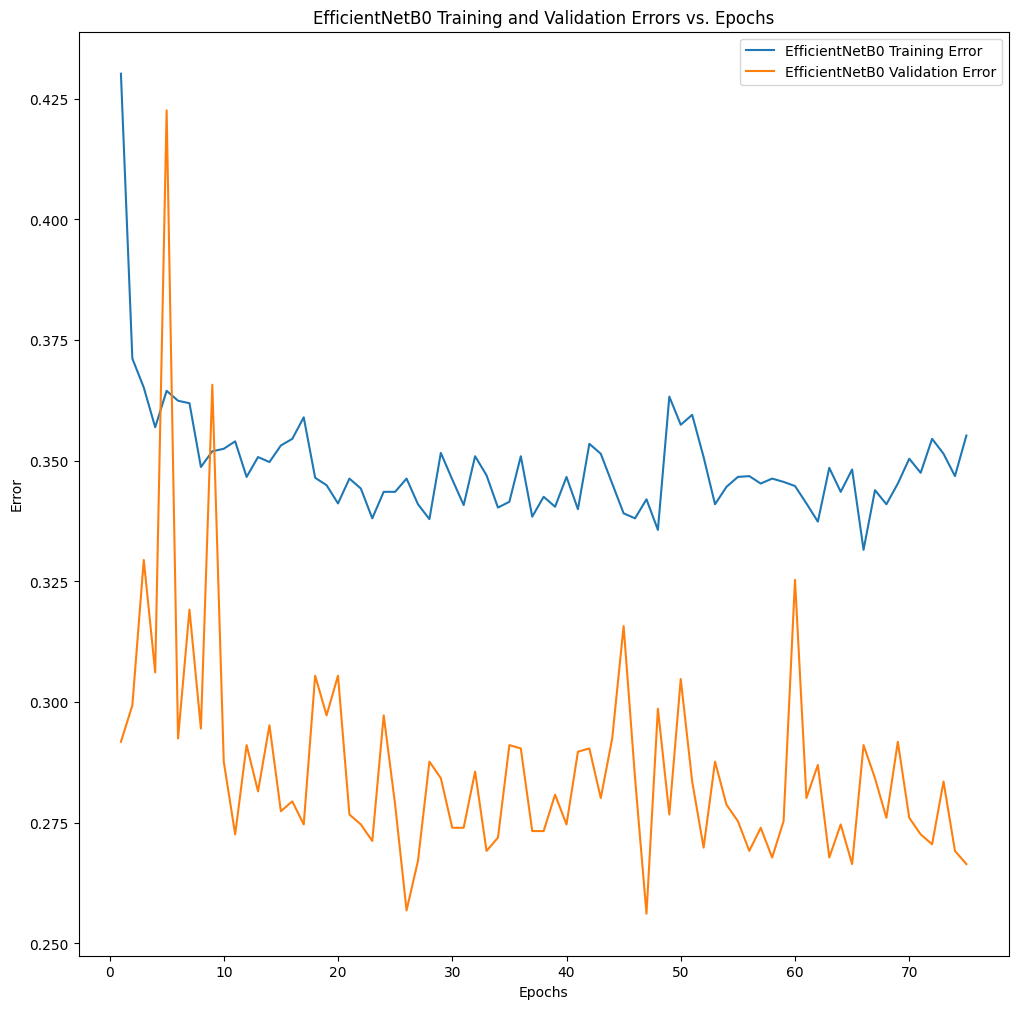

183/183 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step
EfficientNetB0 TRAINING Scores:
	Precision: 0.7078581488615132
	Recall: 0.71852487135506
	F1 Score: 0.6850369846427398
	AUC: 0.8687350173558598
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step
EfficientNetB0 TESTING Scores:
	Precision: 0.6243418025075347
	Recall: 0.6337719298245614
	F1 Score: 0.5860519681144514
	AUC: 0.8177966718794688
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step
EfficientNetB0 VALIDATION Scores:
	Precision: 0.7271237857073098
	Recall: 0.7335616438356164
	F1 Score: 0.7042446581000263
	AUC: 0.8698411276546567


In [23]:
# EfficientNetB0 plot training and validation errors vs. epochs
effnet_train_acc = np.array(history_effnet.history['accuracy'])
effnet_val_acc = np.array(history_effnet.history['val_accuracy'])
effnet_train_error = 1 - effnet_train_acc
effnet_val_error = 1 - effnet_val_acc
effnet_epochs = np.arange(1, len(effnet_train_error) + 1)

plt.figure(figsize=(12, 12))
plt.plot(effnet_epochs, effnet_train_error, label='EfficientNetB0 Training Error')
plt.plot(effnet_epochs, effnet_val_error, label='EfficientNetB0 Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("EfficientNetB0 Training and Validation Errors vs. Epochs")
plt.legend()
plt.show()

# training Precision, Recall, AUC, F1 Score
effnet_Y_train_probs = effnet_fm.predict(X_train)

effnet_Y_train_true = np.argmax(Y_train, axis=1)
effnet_Y_train_pred = np.argmax(effnet_Y_train_probs, axis=1)

effnet_train_precision = precision_score(effnet_Y_train_true, effnet_Y_train_pred, average='weighted', zero_division=0)
effnet_train_recall = recall_score(effnet_Y_train_true, effnet_Y_train_pred, average='weighted', zero_division=0)
effnet_train_f1 = f1_score(effnet_Y_train_true, effnet_Y_train_pred, average='weighted', zero_division=0)
effnet_train_auc = roc_auc_score(Y_train, effnet_Y_train_probs, average='weighted', multi_class='ovr')

print("EfficientNetB0 TRAINING Scores:")
print(f"\tPrecision: {effnet_train_precision}")
print(f"\tRecall: {effnet_train_recall}")
print(f"\tF1 Score: {effnet_train_f1}")
print(f"\tAUC: {effnet_train_auc}")

# testing Precision, Recall, AUC, F1 Score
effnet_Y_test_probs = effnet_fm.predict(X_test)

effnet_Y_test_true = np.argmax(Y_test, axis=1)
effnet_Y_test_pred = np.argmax(effnet_Y_test_probs, axis=1)

effnet_test_precision = precision_score(effnet_Y_test_true, effnet_Y_test_pred, average='weighted', zero_division=0)
effnet_test_recall = recall_score(effnet_Y_test_true, effnet_Y_test_pred, average='weighted', zero_division=0)
effnet_test_f1 = f1_score(effnet_Y_test_true, effnet_Y_test_pred, average='weighted', zero_division=0)
effnet_test_auc = roc_auc_score(Y_test, effnet_Y_test_probs, average='weighted', multi_class='ovr')

print("EfficientNetB0 TESTING Scores:")
print(f"\tPrecision: {effnet_test_precision}")
print(f"\tRecall: {effnet_test_recall}")
print(f"\tF1 Score: {effnet_test_f1}")
print(f"\tAUC: {effnet_test_auc}")

# validation Precision, Recall, AUC, F1 Score
effnet_Y_val_probs = effnet_fm.predict(X_val)

effnet_Y_val_true = np.argmax(Y_val, axis=1)
effnet_Y_val_pred = np.argmax(effnet_Y_val_probs, axis=1)

effnet_val_precision = precision_score(effnet_Y_val_true, effnet_Y_val_pred, average='weighted', zero_division=0)
effnet_val_recall = recall_score(effnet_Y_val_true, effnet_Y_val_pred, average='weighted', zero_division=0)
effnet_val_f1 = f1_score(effnet_Y_val_true, effnet_Y_val_pred, average='weighted', zero_division=0)
effnet_val_auc = roc_auc_score(Y_val, effnet_Y_val_probs, average='weighted', multi_class='ovr')

print("EfficientNetB0 VALIDATION Scores:")
print(f"\tPrecision: {effnet_val_precision}")
print(f"\tRecall: {effnet_val_recall}")
print(f"\tF1 Score: {effnet_val_f1}")
print(f"\tAUC: {effnet_val_auc}")

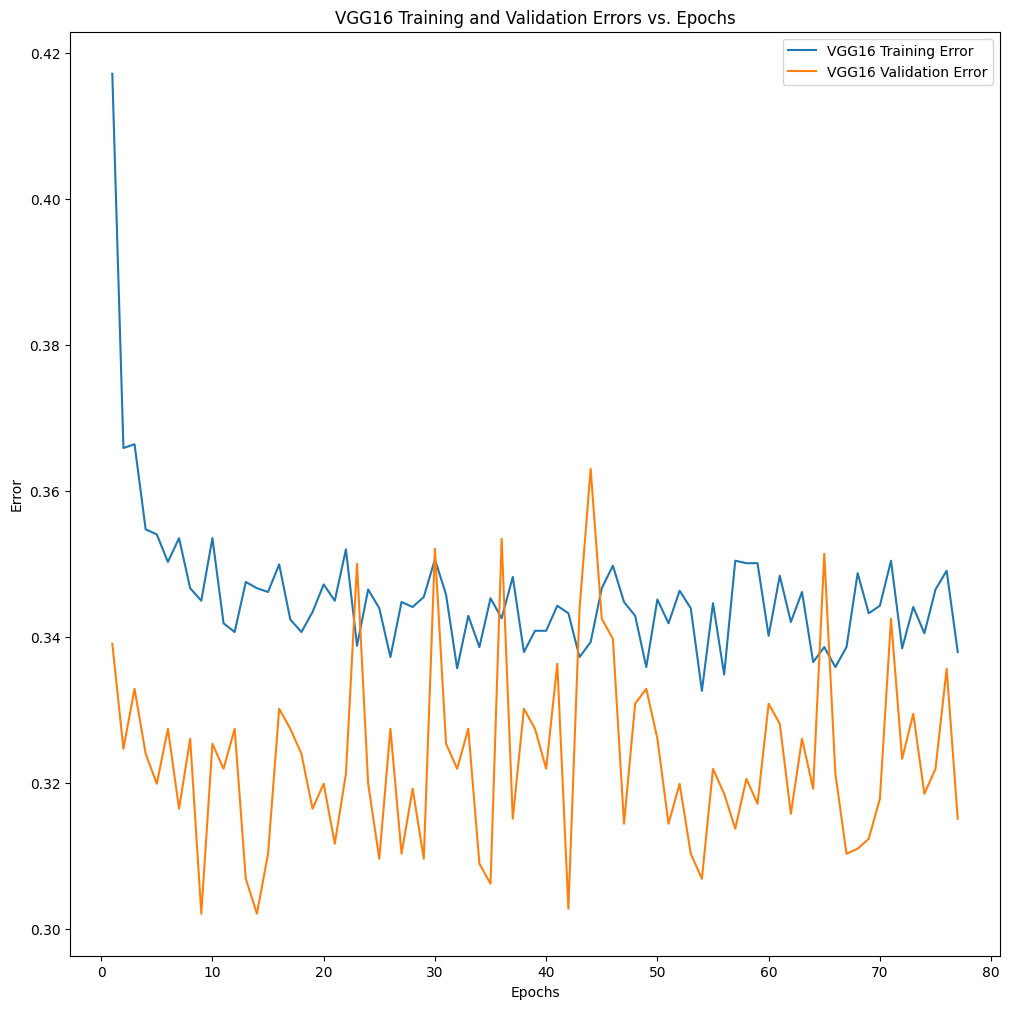

183/183 ━━━━━━━━━━━━━━━━━━━━ 34s 163ms/step
VGG16 TRAINING Scores:
	Precision: 0.7107444495075538
	Recall: 0.6909090909090909
	F1 Score: 0.637593773938384
	AUC: 0.8505106616763551
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step
VGG16 TESTING Scores:
	Precision: 0.5998994998297479
	Recall: 0.6091008771929824
	F1 Score: 0.5377013118185889
	AUC: 0.7825703885507796
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step
VGG16 VALIDATION Scores:
	Precision: 0.6997915214277785
	Recall: 0.6897260273972603
	F1 Score: 0.6393281835652717
	AUC: 0.8559661782492003


In [24]:
# VGG16 plot training and validation errors vs. epochs
vgg_train_acc = np.array(history_vgg.history['accuracy'])
vgg_val_acc = np.array(history_vgg.history['val_accuracy'])
vgg_train_error = 1 - vgg_train_acc
vgg_val_error = 1 - vgg_val_acc
vgg_epochs = np.arange(1, len(vgg_train_error) + 1)

plt.figure(figsize=(12, 12))
plt.plot(vgg_epochs, vgg_train_error, label='VGG16 Training Error')
plt.plot(vgg_epochs, vgg_val_error, label='VGG16 Validation Error')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("VGG16 Training and Validation Errors vs. Epochs")
plt.legend()
plt.show()

# training Precision, Recall, AUC, F1 Score
vgg_Y_train_probs = vgg_fm.predict(X_train)

vgg_Y_train_true = np.argmax(Y_train, axis=1)
vgg_Y_train_pred = np.argmax(vgg_Y_train_probs, axis=1)

vgg_train_precision = precision_score(vgg_Y_train_true, vgg_Y_train_pred, average='weighted', zero_division=0)
vgg_train_recall = recall_score(vgg_Y_train_true, vgg_Y_train_pred, average='weighted', zero_division=0)
vgg_train_f1 = f1_score(vgg_Y_train_true, vgg_Y_train_pred, average='weighted', zero_division=0)
vgg_train_auc = roc_auc_score(Y_train, vgg_Y_train_probs, average='weighted', multi_class='ovr')

print("VGG16 TRAINING Scores:")
print(f"\tPrecision: {vgg_train_precision}")
print(f"\tRecall: {vgg_train_recall}")
print(f"\tF1 Score: {vgg_train_f1}")
print(f"\tAUC: {vgg_train_auc}")

# testing Precision, Recall, AUC, F1 Score
vgg_Y_test_probs = vgg_fm.predict(X_test)

vgg_Y_test_true = np.argmax(Y_test, axis=1)
vgg_Y_test_pred = np.argmax(vgg_Y_test_probs, axis=1)

vgg_test_precision = precision_score(vgg_Y_test_true, vgg_Y_test_pred, average='weighted', zero_division=0)
vgg_test_recall = recall_score(vgg_Y_test_true, vgg_Y_test_pred, average='weighted', zero_division=0)
vgg_test_f1 = f1_score(vgg_Y_test_true, vgg_Y_test_pred, average='weighted', zero_division=0)
vgg_test_auc = roc_auc_score(Y_test, vgg_Y_test_probs, average='weighted', multi_class='ovr')

print("VGG16 TESTING Scores:")
print(f"\tPrecision: {vgg_test_precision}")
print(f"\tRecall: {vgg_test_recall}")
print(f"\tF1 Score: {vgg_test_f1}")
print(f"\tAUC: {vgg_test_auc}")

# validation Precision, Recall, AUC, F1 Score
vgg_Y_val_probs = vgg_fm.predict(X_val)

vgg_Y_val_true = np.argmax(Y_val, axis=1)
vgg_Y_val_pred = np.argmax(vgg_Y_val_probs, axis=1)

vgg_val_precision = precision_score(vgg_Y_val_true, vgg_Y_val_pred, average='weighted', zero_division=0)
vgg_val_recall = recall_score(vgg_Y_val_true, vgg_Y_val_pred, average='weighted', zero_division=0)
vgg_val_f1 = f1_score(vgg_Y_val_true, vgg_Y_val_pred, average='weighted', zero_division=0)
vgg_val_auc = roc_auc_score(Y_val, vgg_Y_val_probs, average='weighted', multi_class='ovr')

print("VGG16 VALIDATION Scores:")
print(f"\tPrecision: {vgg_val_precision}")
print(f"\tRecall: {vgg_val_recall}")
print(f"\tF1 Score: {vgg_val_f1}")
print(f"\tAUC: {vgg_val_auc}")

Transfer Learning v
- Report training, validation, and Test Precision, Recall, AUC, and F1 score for those models
- Is there a model that clearly outperforms others?
- Remember that this is a multi-class classification problem

Scores Put All Togther:

EXAMPLE:
- ResNet50
- ResNet101
- EfficientNetB0
- VGG16

TRAINING PRECISION:
- Precision: 0.7632
- Precision: 0.7730
- Precision: 0.7078
- Precision: 0.7107

TESTING PRECISION:
- Precision: 0.5793
- Precision: 0.5821
- Precision: 0.6243
- Precision: 0.5998

VALIDATION PRECISION:
- Precision: 0.7633
- Precision: 0.7812
- Precision: 0.7271
- Precision: 0.6997

TRAINING RECALL:
- Recall: 0.7614
- Recall: 0.7636
- Recall: 0.7185
- Recall: 0.6909

TESTING RECALL:
- Recall: 0.6014
- Recall: 0.6156
- Recall: 0.6337
- Recall: 0.6091

VALIDATION RECALL:
- Recall: 0.7602
- Recall: 0.7746
- Recall: 0.7335
- Recall: 0.6897

TRAINING F1:
- F1 Score: 0.7390
- F1 Score: 0.7377
- F1 Score: 0.6850
- F1 Score: 0.6375

TESTING F1:
- F1 Score: 0.5516
- F1 Score: 0.5681
- F1 Score: 0.5860
- F1 Score: 0.5377

VALIDATION F1:
- F1 Score: 0.7405
- F1 Score: 0.7538
- F1 Score: 0.7042
- F1 Score: 0.6393

TRAINING AUC:
- AUC: 0.9008
- AUC: 0.9063
- AUC: 0.8687
- AUC: 0.8505

TESTING AUC:
- AUC: 0.8020
- AUC: 0.8231
- AUC: 0.8177
- AUC: 0.7825

VALIDATION AUC:
- AUC: 0.9003
- AUC: 0.9072
- AUC: 0.8698
- AUC: 0.8559


MY ANSWER:
- Based on the outputted scores, I would say that NO MODEL CLEARLY OUTPERFORMS out of the others
- After going through the metrics, ResNet101 got better scores on 8/12 metrics (Training Precision, Validation Precision, Training Recall, Validation Recall, Validation F1, Training AUC, Testing AUC, and Validation AUC)
- EfficientNetB0 got better scores on 3/12 metrics (Testing Precision, Testing Recall, and Testing F1)
- ResNet50 did best on one metric (Training F1)
- VGG16 did NOT do best on any metrics
- If going on the idea that ResNet101 did better on 8/12 (the majority) of the metrics then maybe it is clear, but based off the NUMBERS it is not
- All the numbers for the metrics were relatively close to eachother, showing that each model had relatively the same performance
- For example, the metric with the smallest range is Testing Recall with a range of 0.03 (0.6014, 0.6156, 0.6337, and 0.6091 for ResNet50, ResNet101, EfficientNetB0, and VGG16, respectively)
- - The metric with the largest range is Validation F1 with a range of 0.11 (0.7405, 0.7538, 0.7042, and 0.6393)
- - I'm pointing this out to show that the largest range is only 0.11, showing that all these models were all close to each other
- On top of all this, despite the fact ResNet101 did better on 8/12 total metrics, EfficientNetB0 did better on 3/4 TESTING metrics
- - Based on this, I could say that EfficientNetB0 performed better because it generalized better due to having better scores on a majority of the testing metrics
- So to answer the actual question the project asks: no model clearly outperforms out of the others

REFERENCES, Documentation:
- Keras ResNet50
- - https://www.tensorflow.org/api_docs/python/tf/keras/applications/ResNet50
- Keras ResNet101
- - https://www.tensorflow.org/api_docs/python/tf/keras/applications/ResNet101
- Keras EfficientNetB0
- - https://www.tensorflow.org/api_docs/python/tf/keras/applications/EfficientNetB0
- Keras VGG16
- - https://www.tensorflow.org/api_docs/python/tf/keras/applications/VGG16


REFERENCES, Questions Asked on Search Engines:
- what packages do i need in python to use KEras
- - https://www.google.com/search?q=what+packages+do+i+need+in+python+to+use+KEras&oq=what+packages+do+i+need+in+python+to+use+KEras&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRigATIHCAIQIRifBTIHCAMQIRifBTIHCAQQIRifBTIHCAUQIRifBTIHCAYQIRifBTIHCAcQIRifBTIHCAgQIRifBTIHCAkQIRifBdIBCDc4OTRqMGo3qAIAsAIA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- is it better to resize or zero pad images for neural networks?
- - https://www.google.com/search?q=is+it+better+to+resize+or+zero+pad+images+for+neural+networks%3F&oq=is+it+better+to+resize+or+zero+pad+images+for+neural+networks%3F&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAjIHCAIQIRiPAtIBCDgxMDFqMGo3qAIAsAIA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- what packages do i need to resize images in python
- - https://www.google.com/search?q=what+packages+do+i+need+to+resize+images+in+python&sca_esv=5a206a9c5c2a6b37&biw=746&bih=787&sxsrf=APpeQnuvMSsOTFu7-bCOsTcxm2sBbSGrjQ%3A1784303089134&ei=8U1aavXfB8zCkPIPkJGukQo
- what packages do i need to zero pad images in python
- - https://www.google.com/search?q=what+packages+do+i+need+to+zero+pad+images+in+python&oq=what+packages+do+i+need+to+zero+pad+images+in+python&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRigATIHCAIQIRigATIHCAMQIRigATIHCAQQIRigATIHCAUQIRigAdIBCDU0MjNqMGo5qAIAsAIA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- how do i use resnet50 resnet101 efficientnetB0 and VGG16 in python
- - https://www.google.com/search?q=how+do+i+use+resnet50+resnet101+efficientnetB0+and+VGG16+in+python&sca_esv=5a206a9c5c2a6b37&biw=746&bih=787&sxsrf=APpeQns4KjgPDU4u53bAMOt5HL8-SOnmNQ%3A1784303359414&ei=_05aaofuGIXmkPIP6vOvwQw
- for filenames that look like: H1_100a_3.jpg and H1_101a_1.jpg, how do i make sure H1_100a_3.jpg comes before H1_101a_1.jpg python
- - https://www.google.com/search?q=for+filenames+that+look+like%3A+H1_100a_3.jpg+and+H1_101a_1.jpg%2C+how+do+i+make+sure+H1_100a_3.jpg+comes+before+H1_101a_1.jpg+python&oq=for+filenames+that+look+like%3A+H1_100a_3.jpg+and+H1_101a_1.jpg%2C+how+do+i+make+sure+H1_100a_3.jpg+comes+before+H1_101a_1.jpg+python&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAtIBCTE2NDc1ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- in python to read csv files we do read_csv, what do I do for images?
- - https://www.google.com/search?q=in+python+to+read+csv+files+we+do+read_csv%2C+what+do+I+do+for+images%3F&oq=in+python+to+read+csv+files+we+do+read_csv%2C+what+do+I+do+for+images%3F+&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAjIHCAIQIRiPAtIBCTEyNjQ2ajBqOagCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- what does \d+ capture in re
- - https://www.google.com/search?q=what+does+%5Cd%2B+capture+in+re&oq=what+does+%5Cd%2B+capture+in+re&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRigATIHCAIQIRigATIHCAMQIRigATIHCAQQIRigATIHCAUQIRigATIHCAYQIRirAjIHCAcQIRirAjIHCAgQIRiPAjIHCAkQIRiPAtIBCDU2MDhqMGo3qAIAsAIA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- if i have the path to my entire data folder and the names of the inner folders, how do i create paths to those inner folders
- - https://www.google.com/search?q=if+i+have+the+path+to+my+entire+data+folder+and+the+names+of+the+inner+folders%2C+how+do+i+create+paths+to+those+inner+folders&oq=if+i+have+the+path+to+my+entire+data+folder+and+the+names+of+the+inner+folders%2C+how+do+i+create+paths+to+those+inner+folders&gs_lcrp=EgZjaHJvbWUyBggAEEUYOdIBCTI3Mjk3ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- if i have a folder full of images that resemble H1_100a_3.jpg, how do i give that to python sorted() function
- - https://www.google.com/search?q=if+i+have+a+folder+full+of+images+that+resemble+H1_100a_3.jpg%2C+how+do+i+give+that+to+python+sorted%28%29+function&oq=if+i+have+a+folder+full+of+images+that+resemble+H1_100a_3.jpg%2C+how+do+i+give+that+to+python+sorted%28%29+function&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAtIBCTI3NzY3ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- how do i make a list of .jpgs from a folder of .jpgs python
- - https://www.google.com/search?q=how+do+i+make+a+list+of+.jpgs+from+a+folder+of+.jpgs+python&sca_esv=b754fa5c8f084eb3&sxsrf=APpeQnvsRBaJYVtVymu1PV4IQMokF5EL9w%3A1784339029303&ei=VdpaauuTEqPRkPIPjfznkQ0&biw=746&bih=787&ved=0ahUKEwirkoDwjNuVAxWjKEQIHQ3-OdIQ4dUDCBA&uact=5&oq=how+do+i+make+a+list+of+.jpgs+from+a+folder+of+.jpgs+python&gs_lp=Egxnd3Mtd2l6LXNlcnAiO2hvdyBkbyBpIG1ha2UgYSBsaXN0IG9mIC5qcGdzIGZyb20gYSBmb2xkZXIgb2YgLmpwZ3MgcHl0aG9uMgUQABjvBTIFEAAY7wUyBRAAGO8FMgUQABjvBUi4FVAAWJYUcAJ4AJABAJgBeaABlwOqAQMyLjK4AQPIAQD4AQGYAgagArUDwgIHECEYChigAcICBRAhGKsCmAMAkgcDNC4yoAfFE7IHAzIuMrgHsAPCBwcxLjIuMi4xyAcRgAgB&sclient=gws-wiz-serp
- options for keeping track of the classes each image path in a list of image paths are in where i want separate data structures, not a dictionary
- - https://www.google.com/search?q=options+for+keeping+track+of+the+classes+each+image+path+in+a+list+of+image+paths+are+in+where+i+want+separate+data+structures%2C+not+a+dictionary&sca_esv=b754fa5c8f084eb3&biw=746&bih=787&sxsrf=APpeQnsj4t10qNAZbh90mx6bRh5Gf0e3yA%3A1784340160905&ei=wN5aatvwNtm7kPIP1IC-0A8&ved=0ahUKEwjb0MuLkduVAxXZHUQIHVSAD_oQ4dUDCBA&uact=5&oq=options+for+keeping+track+of+the+classes+each+image+path+in+a+list+of+image+paths+are+in+where+i+want+separate+data+structures%2C+not+a+dictionary&gs_lp=Egxnd3Mtd2l6LXNlcnAikAFvcHRpb25zIGZvciBrZWVwaW5nIHRyYWNrIG9mIHRoZSBjbGFzc2VzIGVhY2ggaW1hZ2UgcGF0aCBpbiBhIGxpc3Qgb2YgaW1hZ2UgcGF0aHMgYXJlIGluIHdoZXJlIGkgd2FudCBzZXBhcmF0ZSBkYXRhIHN0cnVjdHVyZXMsIG5vdCBhIGRpY3Rpb25hcnlIAFAAWABwAHgAkAEAmAEAoAEAqgEAuAEDyAEAmAIAoAIAmAMAkgcAoAcAsgcAuAcAwgcAyAcAgAgB&sclient=gws-wiz-serp
- how to make a list of 1s that is the size of the length of another list
- - https://www.google.com/search?q=how+to+make+a+list+of+1s+that+is+the+size+of+the+length+of+another+list&oq=how+to+make+a+list+of+1s+that+is+the+size+of+the+length+of+another+list&gs_lcrp=EgZjaHJvbWUyBggAEEUYOdIBCTE4NTUwajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- for images that are blurry-ish microscope like, for neural network resnet50, resnet101, efficientnetb0, and vgg16, should i zero pad, resize, or both?
- - https://www.google.com/search?q=for+images+that+are+blurry-ish+microscope+like%2C+for+neural+network+resnet50%2C+resnet101%2C+efficientnetb0%2C+and+vgg16%2C+should+i+zero+pad%2C+resize%2C+or+both%3F&sca_esv=b754fa5c8f084eb3&sxsrf=APpeQnvCxjALphySQW-ilUBcNbhAj_FJkw%3A1784341545535&ei=KeRaatKhIPnekPIPpZnbQA&biw=746&bih=787&ved=0ahUKEwiS2uqfltuVAxV5L0QIHaXMFggQ4dUDCBA&uact=5&oq=for+images+that+are+blurry-ish+microscope+like%2C+for+neural+network+resnet50%2C+resnet101%2C+efficientnetb0%2C+and+vgg16%2C+should+i+zero+pad%2C+resize%2C+or+both%3F&gs_lp=Egxnd3Mtd2l6LXNlcnAilgFmb3IgaW1hZ2VzIHRoYXQgYXJlIGJsdXJyeS1pc2ggbWljcm9zY29wZSBsaWtlLCBmb3IgbmV1cmFsIG5ldHdvcmsgcmVzbmV0NTAsIHJlc25ldDEwMSwgZWZmaWNpZW50bmV0YjAsIGFuZCB2Z2cxNiwgc2hvdWxkIGkgemVybyBwYWQsIHJlc2l6ZSwgb3IgYm90aD9IAFAAWABwAHgBkAEAmAEAoAEAqgEAuAEDyAEA-AEBmAIAoAIAmAMAkgcAoAcAsgcAuAcAwgcAyAcAgAgB&sclient=gws-wiz-serp
- what image size does resnet50, resnet101, efficientnetb0, and vgg16 take?
- - https://www.google.com/search?q=what+image+size+does+resnet50%2C+resnet101%2C+efficientnetb0%2C+and+vgg16+take%3F&oq=what+image+size+does+resnet50%2C+resnet101%2C+efficientnetb0%2C+and+vgg16+take%3F&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAjIHCAIQIRiPAtIBCTExNTM1ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- for coding, does the color channels do anything or should i just resize and zero pad?
- - https://www.google.com/search?q=what+image+size+does+resnet50%2C+resnet101%2C+efficientnetb0%2C+and+vgg16+take%3F&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAjIHCAIQIRiPAtIBCTExNTM1ajBqN6gCALACAA&sourceid=chrome&ie=UTF-8&udm=50&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8c4u0nXx4bEIpwm1lnNH832QufJlY6zJud3Z__pVf55T9h1SQFki2XCYpJtchR_BvDOKWh4dKJPb3wwTxoGKFGBMIzh6_Wmtc6KJZvJXkuQ_0SB_4dKcpfQIf-cI3-_7osf26-TkqAHtCIJBPLM0in3IVAxJIPz0FDwFdGebkZJrQqMUDDZ765N3wpTuUNgFHpTW2wcg&aep=10&ntc=1&mstk=AUtExfA7YztHpXVRAQEegKyGNhh7zilhi-6QMiyJ_C_L8gBWIgaFbokRAHfUTiAHuV7CxXeA2JlIGnTK4ZIgF-od-PrmCd-JEk3KYB7Dmh_FimYJ8L1TQNdF8fheuCzPmB69ugqDcOD16iX-L6ZbZXzLpOrLUDQ7tNziWG4&aioh=3&csuir=1&cs=0&ccb=1&hl=en-US&biw=746&bih=787&mtid=tuVaar6JILXKkPIPyYS6iA0
- if i make all images RGB at first, will vgg16 preprocess convert it back to BGR?
- - https://www.google.com/search?q=if+i+make+all+images+RGB+at+first%2C+will+vgg16+preprocess+convert+it+back+to+BGR%3F&oq=if+i+make+all+images+RGB+at+first%2C+will+vgg16+preprocess+convert+it+back+to+BGR%3F&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAjIHCAIQIRiPAjIHCAMQIRiPAtIBCTQzNDY3ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- how to convert an image to RGB python opencv
- - https://www.google.com/search?q=how+to+convert+an+image+to+RGB+python+opencv&oq=how+to+convert+an+image+to+RGB+python+opencv&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRigATIHCAIQIRigATIHCAMQIRigATIHCAQQIRigATIHCAUQIRigATIHCAYQIRiPAtIBCDU5MzlqMGo5qAIAsAIA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- how to resize and zero pad images using cv2 to make them 224 x 224 pixels using 3 color channels
- - https://www.google.com/search?q=how+to+resize+and+zero+pad+images+using+cv2+to+make+them+224+x+224+pixels+using+3+color+channels&oq=how+to+resize+and+zero+pad+images+using+cv2+to+make+them+224+x+224+pixels+using+3+color+channels&gs_lcrp=EgZjaHJvbWUyBggAEEUYOdIBCTIwOTA3ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- h, w, c = img.shape -> how do i do this just getting h and w
- - https://www.google.com/search?q=h%2C+w%2C+c+%3D+img.shape+-%3E+how+do+i+do+this+just+getting+h+and+w&oq=h%2C+w%2C+c+%3D+img.shape+-%3E+how+do+i+do+this+just+getting+h+and+w&gs_lcrp=EgZjaHJvbWUyBggAEEUYOdIBCDY5OTFqMGo5qAIGsAIB8QVPwSRZZjSejw&sourceid=chrome&source=chrome.ob&ie=UTF-8
- how to encode my classes using one hot encode
- - https://www.google.com/search?q=how+to+encode+my+classes+using+one+hot+encode&oq=how+to+encode+my+classes+using+one+hot+encode&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRigATIHCAIQIRigATIHCAMQIRigATIHCAQQIRirAjIHCAUQIRifBdIBCTMxNTczajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- using keras in python how do i randomly crop / zoom / rotate / flip / contrast / translate images for better generalization
- - https://www.google.com/search?q=using+keras+in+python+how+do+i+randomly+crop+%2F+zoom+%2F+rotate+%2F+flip+%2F+contrast+%2F+translate+images+for+better+generalization&oq=using+keras+in+python+how+do+i+randomly+crop+%2F+zoom+%2F+rotate+%2F+flip+%2F+contrast+%2F+translate+images+for+better+generalization+&gs_lcrp=EgZjaHJvbWUyBggAEEUYOdIBCTIyOTM3ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- Wouldn’t cropping the image not be good for the sizing needed for resnet50 etc?
- - https://www.google.com/search?q=using+keras+in+python+how+do+i+randomly+crop+%2F+zoom+%2F+rotate+%2F+flip+%2F+contrast+%2F+translate+images+for+better+generalization&gs_lcrp=EgZjaHJvbWUyBggAEEUYOdIBCTIyOTM3ajBqN6gCALACAA&sourceid=chrome&ie=UTF-8&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8cn05EoNqnRUpRtqDK_L3JtfpDfxUZqBhK75N4XIQD_SVFd8hKovculOQPmF1g4kawcAu1PTtKrcbGE_8xF81evSYmqij0-_iCUWFuY6KbUoAgTSpiOLlTtT9yjfC_MT0awdBnFLdHV0PnjRQ4pFb51Q3XYn74Iw10IcP3Dm28sJwIVUXRONI6tGKMUufYdrSDi-4uxg&aep=10&ntc=1&mstk=AUtExfDQ6gbv6cI81uvYRMIs9hoc-3D_ldvPr_pJ1DnBldzWxgUxTMlO4fU35qHt3Jv3IOe08fsBFgyxNdCY5gdhyvVio5lQdw7vMk4ZCrfeKp-pf-EwaHXwT79VfUHAAL-PTKNNFSDxy5Byy9ohQRP_GTPt2KiCdE8_8CzMePZUkziQdoO1fP4azvVsiGskPW3MukGz7UssR19X8em0Z9xt-YLG5q63v-Oj6vEVosmY8kk-NgbvXXot3cnuyBFMSs7hl-IvXBN6K5XoAw&aioh=3&csuir=1&cs=0&ccb=1&hl=en-US&biw=746&bih=787&mtid=m_1aavvHI-nBkPIPyqmg4AQ&udm=50
- how do i load a model like resnet50 and freeze all pretrained layers? python keras
- - https://www.google.com/search?q=how+do+i+load+a+model+like+resnet50+and+freeze+all+pretrained+layers%3F+python+keras&sca_esv=7f0afca09ada6425&sxsrf=APpeQnuhNJ_ZvNqvr7NAdRXYdvPhylvfaQ%3A1784348628350&ei=1P9aauX-FObNkPIP9uXjqQE&biw=746&bih=787&ved=0ahUKEwjluJfRsNuVAxXmJkQIHfbyOBUQ4dUDCBA&uact=5&oq=how+do+i+load+a+model+like+resnet50+and+freeze+all+pretrained+layers%3F+python+keras&gs_lp=Egxnd3Mtd2l6LXNlcnAiUmhvdyBkbyBpIGxvYWQgYSBtb2RlbCBsaWtlIHJlc25ldDUwIGFuZCBmcmVlemUgYWxsIHByZXRyYWluZWQgbGF5ZXJzPyBweXRob24ga2VyYXNIAFAAWABwAHgBkAEAmAEAoAEAqgEAuAEDyAEA-AEBmAIAoAIAmAMAkgcAoAcAsgcAuAcAwgcAyAcAgAgB&sclient=gws-wiz-serp
- if i already have images for resnet50 in keras that are preprocessed already but need to be augmented (data_augmentation already made), how do i do that
- - https://www.google.com/search?q=if+i+already+have+images+for+resnet50+in+keras+that+are+preprocessed+already+but+need+to+be+augmented+%28data_augmentation+already+made%29%2C+how+do+i+do+that&oq=if+i+already+have+images+for+resnet50+in+keras+that+are+preprocessed+already+but+need+to+be+augmented+%28data_augmentation+already+made%29%2C+how+do+i+do+that&gs_lcrp=EgZjaHJvbWUyBggAEEUYOdIBCTI1ODU5ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- resnet50 preprocess function
- - https://www.google.com/search?q=resnet50+preprocess+function&oq=resnet50+preprocess+function&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRigATIHCAIQIRigATIHCAMQIRigATIHCAQQIRigATIHCAUQIRirAjIHCAYQIRiPAtIBCDY2NjNqMGo3qAIAsAIA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- does x = data_augmentation(inputs) not activate the augmentation? do i need training=True or training=False. we made it false earlier since we want to keep the layers frozen
- - https://www.google.com/search?q=if+i+already+have+images+for+resnet50+in+keras+that+are+preprocessed+already+but+need+to+be+augmented+%28data_augmentation+already+made%29%2C+how+do+i+do+that&sca_esv=1eecbfff611c23de&biw=746&bih=787&sxsrf=APpeQnt-CEsIhWUqobVfOZ2zYagRD3ggjw%3A1784349775293&ei=TwRbavbEEZjBkPIP__ftuAE&uact=5&sclient=gws-wiz-serp&udm=50&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8cn05EoNqnRUpRtqDK_L3JtcaVe4agnDpGKPxtn7rLKbiMHV-8WB4Ow6722n3JgwQ0aaTItWPUDeyEqrsxYoNx5SfPn0_L7pJEz5pdrku1aHUsrtyGAI5G6KcfztRnsw9jUqTc9YJutEzHjSBANT6EdCMD-PjxflYrlHkgHx2tIDaTIwVg_PUtUu9iVibiv5oA6v_Ytg&aep=10&ntc=1&mstk=AUtExfCWqvbzwuLzZeHcV6VGZOJJMQHhuCMJB9IXWoTxun7f6-zZUQ09Rsi3pBbQMEf2mDBYC2GcMGMm_XSETDnmOENY7M79QcnboHoWaddXJrqZmkb7QK_za06QJbaYpNgqzNaLFre5JbujLf-fESQIj_LArvhdIOopcszgLXjneFgZBnUTz4nJLvTpbsvj_jnWiz8Ew7y0xQeZWQwkJgmz4K9jstFnKRsYNrhd26CUAWXn7J1IIXcEH7QYmPKD1opTU_SmmXD9OKxrog&aioh=3&csuir=1&cs=0&sourceid=chrome&ccb=1&hl=en-US&mtid=MgZbasj5GtDZkPIPnpHZ4As
- for resnet50 what does batchnormalization in inference mode mean
- - https://www.google.com/search?q=for+resnet50+what+does+batchnormalization+in+inferenc+mode+mean&oq=for+resnet50+what+does+batchnormalization+in+inferenc+mode+mean&gs_lcrp=EgZjaHJvbWUyBggAEEUYOdIBCDUxOTBqMGo3qAIAsAIA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- what does resnet 50 keras GlobalAveragePooling2D() do
- - https://www.google.com/search?q=what+does+resnet+50+keras+GlobalAveragePooling2D%28%29+do&oq=what+does+resnet+50+keras+GlobalAveragePooling2D%28%29+do&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRigATIHCAIQIRigATIHCAMQIRigATIHCAQQIRigATIHCAUQIRiPAtIBCDQ3OTJqMGo3qAIAsAIA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- for resnet50 keras how do I do: relu activation functions in last layer, softmax layer, l2 regularization, batch normalization, dropout rate of 20%, ADAM optimizer, multinomial cross entropy loss, and batch size of 5
- - https://www.google.com/search?q=for+resnet50+keras+how+do+I+do%3A+relu+activation+functions+in+last+layer%2C+softmax+layer%2C+l2+regularization%2C+batch+normalization%2C+dropout+rate+of+20%25%2C+ADAM+optimizer%2C+multinomial+cross+entropy+loss%2C+and+batch+size+of+5&sca_esv=0bf0b030a0d6e361&sxsrf=APpeQnt05RyHmXTZu5MJJQtp58hDbH8cKQ%3A1784397312674&ei=AL5barHXKP_ckPIPud6T2As&biw=746&bih=787&uact=5&sclient=gws-wiz-serp&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8cn05EoNqnRUpRtqDK_L3JtT0h7PdEdL8le1RT1QApqDmPteexoBhHnKokANY29NfXnpANdkWbb-b5aFwp_qBfzxzDhIgcmxl9g_39wcujQlYjsacs1Wl6f76Wlsr-YAO2nSjwy9mKY6Ko9aOgOHSw1eAGuM7Ul3s88de3hlPOog3LtylWR5Ym7b1B8BSc3OOGXbb6jQ&aep=10&ntc=1&mstk=AUtExfCM1SRnbjtySTz2w9vH2iusIPToFgj0kq3tIy74rCmXrg0WPfvV7zGSjvhrRyLX5dDLgaJJoCcQRv8FKWT4YDQ5yHm0N1o3PuLAAZpMU2hzeeJEReH4jFsKwY6oIrk5ovQ-knaBp__bxaMr0JMgha8Rhc2cZT_O__Y8Rq4-MMCj9I3mLgnlINYUinHppfUi60NifOKp7IfPaumUa0YV6lKGlVcRdAGRPNjlrxxXogiFxvRKgvgFnzKpVSW9LMzht9nu9Q06_U22FQ&aioh=3&csuir=1&cs=0&sourceid=chrome&ccb=1&hl=en-US&mtid=B79bavriGdvzkPIPxfbKqQk&udm=50
- after compiling my resnet50 model in keras python, how do i introduce a batch size of 5?
- - https://www.google.com/search?q=after+compiling+my+resnet50+model+in+keras+python%2C+how+do+i+introduce+a+batch+size+of+5%3F&oq=after+compiling+my+resnet50+model+in+keras+python%2C+how+do+i+introduce+a+batch+size+of+5%3F&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAjIHCAIQIRiPAjIHCAMQIRiPAtIBCTEyMTU5ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- how do i put my validation set into resnet50 fit keras python
- - https://www.google.com/search?q=how+do+i+put+my+validation+set+into+resnet50+fit+keras+python&sca_esv=0764ec3eacfc6f66&sxsrf=APpeQnvU8ER0qryxSzXNOquIuw28vwGwhw%3A1784399096363&ei=-MRbaqnkFfbnkPIP9YrLeA&biw=746&bih=787&ved=0ahUKEwipwJrS7NyVAxX2M0QIHXXFEg8Q4dUDCBI&uact=5&oq=how+do+i+put+my+validation+set+into+resnet50+fit+keras+python&gs_lp=Egxnd3Mtd2l6LXNlcnAiPWhvdyBkbyBpIHB1dCBteSB2YWxpZGF0aW9uIHNldCBpbnRvIHJlc25ldDUwIGZpdCBrZXJhcyBweXRob24yBRAhGKABMgUQIRigATIFECEYoAEyBRAhGKABSI4TUABY6BFwA3gAkAEAmAGYAaABxQiqAQM4LjO4AQPIAQD4AQGYAg2gAoEIwgIFECEYnwXCAgUQIRirApgDAJIHBDExLjKgB8ZAsgcDOC4yuAf9B8IHBjIuMTAuMcgHFIAIAQ&sclient=gws-wiz-serp
- how do i upload my jupyter notebook in github to google colab in order to use google colab GPUs
- - https://www.google.com/search?q=how+do+i+upload+my+jupyter+notebook+in+github+to+google+colab+in+order+to+use+google+colab+GPUs&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAjIHCAIQIRiPAtIBCTE1Mjg3ajBqN6gCALACAA&sourceid=chrome&ie=UTF-8&udm=50&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8cqu7ocb7U6ah0xpkIrGMK4LpKPoHZrc4HVz9uOAATjT1WBZlsmp16AtPwl2JD0qSy_O2ju2c2Jptc1EOmM28-b8Udopzf8P0kdJB8M3p5q8VaE92atPNve65kUMs09qPPMU2U2gRzjqjTnvFarAUKw0YkCg6gdPcF0vto5ATgbtMONVEh6KWHutcyfkEfDasvAQcvCQ&aep=10&ntc=1&mstk=AUtExfDnONLHxHaR_BL065dDsV_mdaVIO1GkHBuKEXwIYSuWkyQTvi5tWiqK2J8juJ6aS0mL8osC5hxW80PtOPM2cGSM3ucOK7R57MugSS0VPo7DRnMg1GhdCElbg-6XVdP8ADRgAgBJLOySbMoUgznyqY9KPxEB8Ltqsr4&aioh=3&csuir=1&cs=0&ccb=1&hl=en-US&biw=1355&bih=787&mtid=dchbavvuKvOhur8PjL_JsAs
- using resnet50 keras how do i do early stopping using a validation set
- - https://www.google.com/search?q=using+resnet50+keras+how+do+i+do+early+stopping+using+a+validation+set&oq=using+resnet50+keras+how+do+i+do+early+stopping+using+a+validation+set&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAjIHCAIQIRiPAtIBCTEwNDA4ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- for resnet50 keras how do i keep the network parameters that have the lowest validation error
- - https://www.google.com/search?q=for+resnet50+keras+how+do+i+keep+the+network+parameters+that+have+the+lowets+validation+error&oq=for+resnet50+keras+how+do+i+keep+the+network+parameters+that+have+the+lowets+validation+error&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAtIBCTE4MTc5ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- for resnet50 keras modelcheckpoint, what should the file name be if i do save_best_only=True and save_weights_only=True
- - https://www.google.com/search?q=for+resnet50+keras+modelcheckpoint%2C+what+should+the+file+name+be+if+i+do+save_best_only%3DTrue+and+save_weights_only%3DTrue&oq=for+resnet50+keras+modelcheckpoint%2C+what+should+the+file+name+be+if+i+do+save_best_only%3DTrue+and+save_weights_only%3DTrue&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAjIHCAIQIRiPAtIBCTM0MTE5ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- how do i get training error out of ModelCheckpoint keras
- - https://www.google.com/search?q=how+do+i+get+training+error+out+of+ModelCheckpoint+keras&sca_esv=a2aa25b18da7571d&sxsrf=APpeQnuhm5pYLsexlsARmOOAsKAkjsIJzw%3A1784407662341&ei=buZbaq27FPGSvMcPhbe2sQ0&biw=696&bih=787&uact=5&sclient=gws-wiz-serp&udm=50&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8cqu7ocb7U6ah0xpkIrGMK4LpKPoHZrc4HVz9uOAATjT1WBZlsmp16AtPwl2JD0qSy_O2ju2c2Jptc1EOmM28-b8Udopzf8P0kdJB8M3p5q8VaE92atPNve65kUMs09qPPMU2U2gRzjqjTnvFarAUKw0YkCg6gdPcF0vto5ATgbtMONVEh6KWHutcyfkEfDasvAQcvCQ&aep=10&ntc=1&mstk=AUtExfAFhD_2fwBNTj0yflvFJjTU8q-1W-y9VO-ialiVgkmAlqQShccG4K3HeU1tYGrCmzKlIG9uybQq73DQkEas-sSc4j06NboqbiQ22d1-BajDMQR9Pnq1V3NBXmwC8KFTacFaGrHZJHWrTUg75V-hqDokJliLTRDUIAuXSlXY97NccjFlDSO5ZeyD2cdh-Rrgl9idSyTJWkzDzlcAsatdiCzGmrrOYx_t_Iv03EDnI7YvRMUwgmclVbYlRmcv2wa0XYEXm6A5K-7Utw&aioh=3&csuir=1&cs=0&sourceid=chrome&ccb=1&hl=en-US&mtid=t-Zbau_9CYeRvMcP0a3wwAU
- what does precision score python take
- - https://www.google.com/search?q=what+does+precision+score+python+take&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRigATIHCAIQIRigATIHCAMQIRigATIHCAQQIRiPAtIBCDUyNThqMGo5qAIGsAIB8QV2RCWshGaJ7A&sourceid=chrome&ie=UTF-8&udm=50&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8cn05EoNqnRUpRtqDK_L3JtcaVe4agnDpGKPxtn7rLKbh9RiMyQNxAO2alE80HFcj3iNW7x4D00ceR_WPJ-usEAUxyJ0ZBTrhZOovk8UBpI09vHoyYJN2jqFLVoQpzM-RJle_dEaGonu93fPr5u5rjdAWTbgZ8NLG6j6rgaSjlztBmb0zRnw3vqoG1rYkawmqLjePzRA&aep=10&ntc=1&mstk=AUtExfDEyWeZj3JdfOc1uDhpZWot4qNiZKnjj7kOotF51Dp_JO5FIuOTEr6yOpd9qUC5URzdBWpFHT9KA3gBA_RqbWIQ5A7M_EL0-QxHyQIhZgQXXxzzB3wOg4Ur-hsUjQC-9v4MKyYIag8kdeGxczsPwQ1uUtR9UM68ia0&aioh=3&csuir=1&cs=0&ccb=1&hl=en-US&biw=696&bih=787&mtid=1upbasPzBoygkPIP66HJsA8
- for precision, recall, auc, and f1 score in python, for which ones should i convert my previously one-hot encoded data?
- - https://www.google.com/search?q=for+precision%2C+recall%2C+auc%2C+and+f1+score+in+python%2C+for+which+ones+should+i+convert+my+previously+one-hot+encoded+data%3F&oq=for+precision%2C+recall%2C+auc%2C+and+f1+score+in+python%2C+for+which+ones+should+i+convert+my+previously+one-hot+encoded+data%3F&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAjIHCAIQIRiPAtIBCTE4NzY5ajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
- how do i make sure in modelcheckpoint keras that a model like resnet50 runs for at MINIMUM 50 epochs
- - https://www.google.com/search?q=how+do+i+make+sure+in+modelcheckpoint+keras+that+a+model+like+resnet50+runs+for+at+MINIMUM+50+epochs&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAjIHCAIQIRiPAtIBCTE1MjQwajBqN6gCALACAA&sourceid=chrome&ie=UTF-8&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8cqu7ocb7U6ah0xpkIrGMK4LpKPoHZrc4HVz9uOAATjT1g2XbMUNYTWk-OmYpiK--qLizoF5Vfe_ozYlUxaDSbKTolzeP6fvdnXhcHYbEdwKwihAtOtXaXzrJn9JYf6QZOMHnCuIavpvsLhpG8F5NaG9y1EUsfRjgcUxIQ_CGU2AvjDCda5s6nzrwZR_mb8S6R1JgOYg&aep=10&ntc=1&mstk=AUtExfD4TtM_Gl8KT2DPd8bbrFVhHgwpaT0AW9Esjfhl3N5mZdaQy_xK0zkbWOAVJFfJmlv1Z9sfowjTTx0jGRrp6RhAS8cFCmL9tmH-LTIcbij81ZDloRX7sJcjw8pgCuAKBM0zS6uUvyg_a5D6cAinUMD_4NsEgcCqMdZfJR6tpJFxF1fAQd9BTvBeYnTw1nseOUdB_43dFTQWsIHOtiMVYYDc_oDAnZtr_A23-tkr21hRvM-0z51bL33ppOFUBLnYVe0wI8V7Af2pUw&aioh=3&csuir=1&cs=0&ccb=1&hl=en-US&biw=696&bih=787&mtid=cyZcapuHDY2Qur8PjPfUgAI&udm=50
- when should i do .fit_transform and just .transform when using OneHotEncoder? i have ytrain ytest and yvalidation
- - https://www.google.com/search?q=when+should+i+do+.fit_transform+and+just+.transform+when+using+OneHotEncoder%3F+i+have+ytrain+ytest+and+yvalidation&oq=when+should+i+do+.fit_transform+and+just+.transform+when+using+OneHotEncoder%3F+i+have+ytrain+ytest+and+yvalidation&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRiPAtIBCTI0MDUwajBqN6gCALACAA&sourceid=chrome&source=chrome.ob&ie=UTF-8
